## 1. Load and preprocess MNIST

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# Load dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize images
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape for CNN
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 35s 3us/step
Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


## 2. Add Artificial Noise

In [5]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape)

# Keep pixel values in range [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

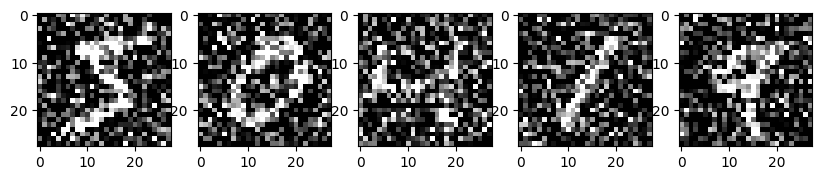

In [7]:
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
plt.show()

## 3. Build Denoising Autoencoder

In [9]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train Model

In [11]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 125s 248ms/step - loss: 0.2588 - val_loss: 0.1179
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 240ms/step - loss: 0.1156 - val_loss: 0.1088
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 240ms/step - loss: 0.1089 - val_loss: 0.1052
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 212ms/step - loss: 0.1056 - val_loss: 0.1043
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 95s 204ms/step - loss: 0.1035 - val_loss: 0.1015
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 151ms/step - loss: 0.1021 - val_loss: 0.1003
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - loss: 0.1009 - val_loss: 0.0993
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - loss: 0.1000 - val_loss: 0.0987
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - loss: 0.0993 - val_loss: 0.0981
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 100ms/step - loss: 0.0989 - val_loss: 0.0979


## 5. Generate Denoised Outputs

In [20]:
denoised_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


## 6. Visual Results

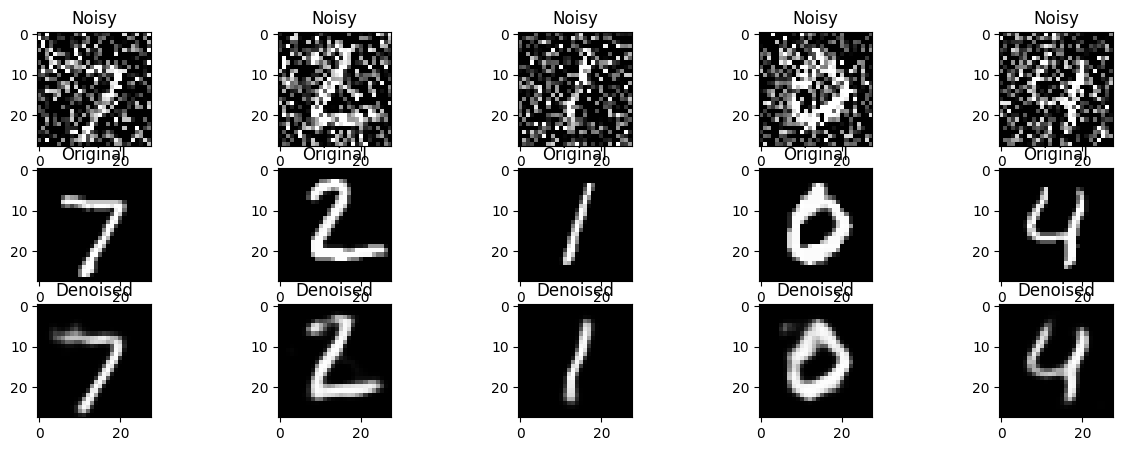

In [22]:
n = 5
plt.figure(figsize=(15,5))

for i in range(n):

    # Noisy
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")

    # Original
    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")

    # Denoised
    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(denoised_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")

plt.show()